# Lab 7.07 - Time series analysis

In [6]:
# Package imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

## Exercise 7: golden cross

A *Golden Cross* is the name of a pattern that is used in the technical analysis of stock prices. A Golden Cross occurs when a short-term moving average breaks above a long-term moving average. This is an indicator for the potential of a major rally on the stock (*bull market*). The long-term moving average is then considered to be a "resistance level", i.e. when the stock price drops towards that level, it will often quickly bounce up again.

The dataset `SP500.csv` contains among others the closing price of the Standard & Poors 500, a stock market index tracking the performance of 500 large publicly traded companies in the USA. The data was collected by Hoseinzade & Haratizadeh (2019).

- Import the CSV-file in a DataFrame, parse the `Date` column as a date and set it as the index. We will only use the variable `Close`, so you can drop all other variables.
- Plot the time series to get an idea about the evolution over time of the S&P500 index.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import S&P 500 data
data = pd.read_csv(
    'https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/SP500.csv',
    parse_dates=['Date']
).set_index(['Date'])

# Keep only the Close column
data = data[['Close']].copy()

print(data.head())

                  Close
Date                   
2009-12-31  1115.099976
2010-01-04  1132.989990
2010-01-05  1136.520020
2010-01-06  1137.140015
2010-01-07  1141.689941


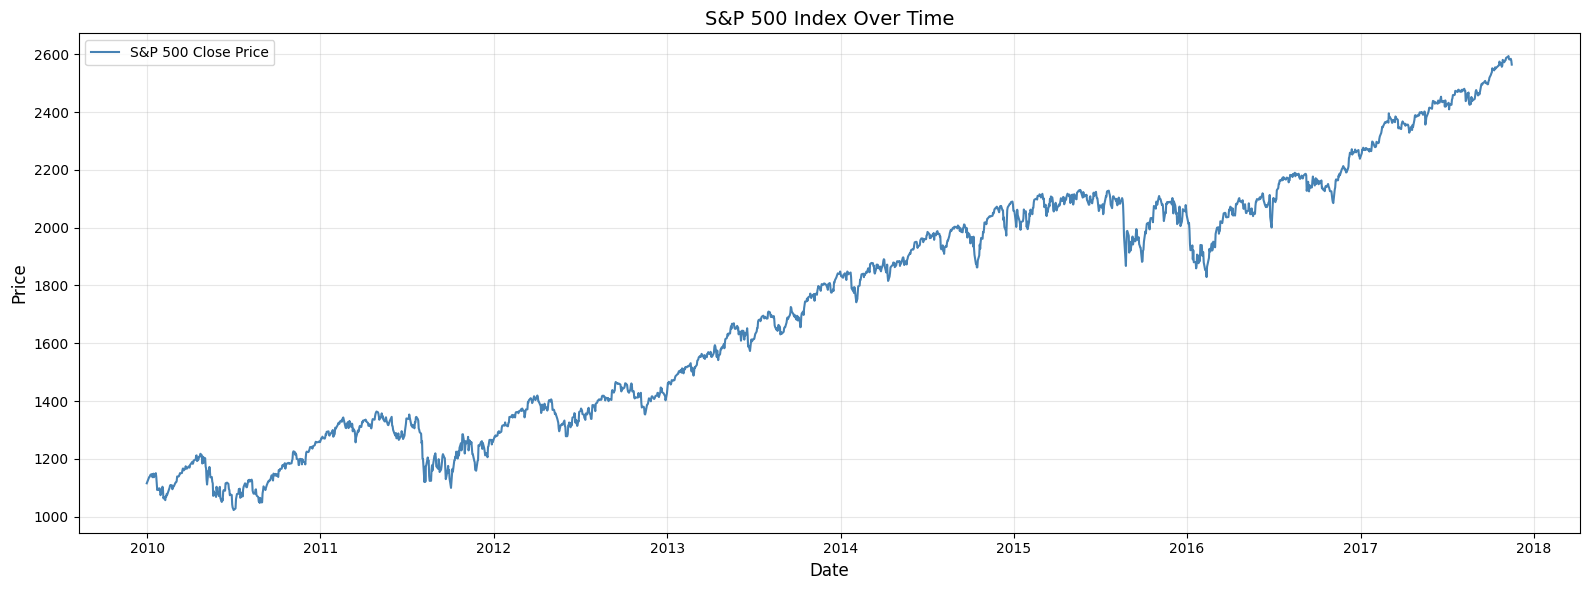

In [8]:
plt.figure(figsize=(16, 6))
plt.plot(data.index, data['Close'], linewidth=1.5, color='steelblue', label='S&P 500 Close Price')
plt.title('S&P 500 Index Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Traders often use moving averages when analysing the evolution of stock prices. Specifically, the 50-day moving average is the average price over the last 10 trading weeks, making it a commonly used support level. Likewise, the 200-day moving average represents the average price over the past 40 weeks, which is used to suggest a relatively cheap price compared to the price range over most of the past year.

- Calculate the 50- and 200-day moving average and add the result as new columns in the DataFrame with names `MA50` and `MA200`, respectively.

In [9]:
# Calculate moving averages
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

print(data.head(250))

                  Close         MA50        MA200
Date                                             
2009-12-31  1115.099976          NaN          NaN
2010-01-04  1132.989990          NaN          NaN
2010-01-05  1136.520020          NaN          NaN
2010-01-06  1137.140015          NaN          NaN
2010-01-07  1141.689941          NaN          NaN
...                 ...          ...          ...
2010-12-21  1254.599976  1203.879993  1142.644146
2010-12-22  1258.839966  1205.661392  1143.210296
2010-12-23  1256.770020  1207.234792  1143.742946
2010-12-27  1257.540039  1208.909392  1144.280697
2010-12-28  1258.510010  1210.555793  1144.820697

[250 rows x 3 columns]


- Plot the S&P500 index with both moving averages


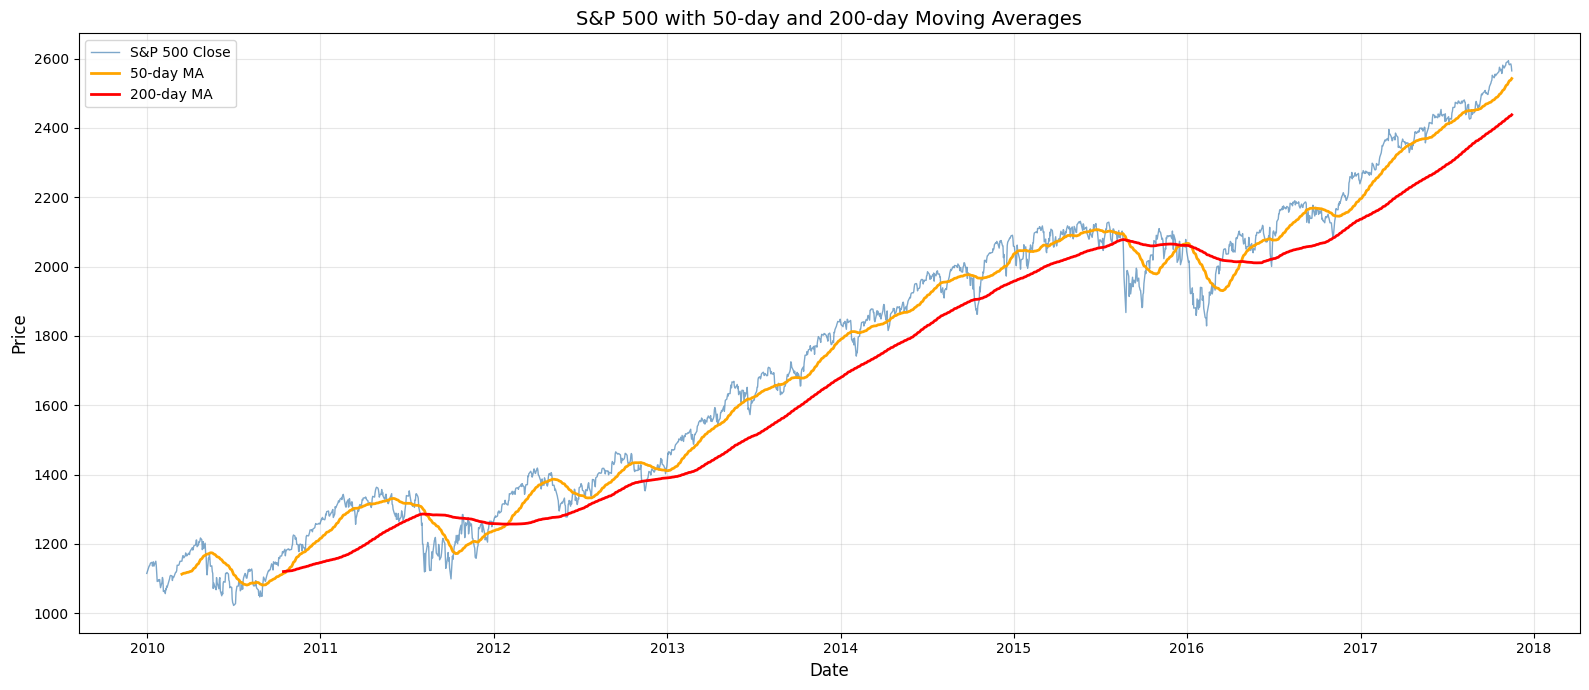

In [10]:
plt.figure(figsize=(16, 7))

plt.plot(data.index, data['Close'], label='S&P 500 Close', linewidth=1, color='steelblue', alpha=0.7)
plt.plot(data.index, data['MA50'], label='50-day MA', linewidth=2, color='orange')
plt.plot(data.index, data['MA200'], label='200-day MA', linewidth=2, color='red')

plt.title('S&P 500 with 50-day and 200-day Moving Averages', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


- In August 2011, stock markets across the world [saw a sharp drop in stock prices](https://en.wikipedia.org/wiki/August_2011_stock_markets_fall), due to the [European sovereign debt crisis](https://en.wikipedia.org/wiki/European_debt_crisis). Look for that drop in the plot.
- After the 2011 stock markets fall, there are *two* occurrences of a golden cross.
- Both occurrences mark the beginning of long periods with a *bull market* (characterized by rising prices). If possible, identify how long each period lasted, i.e. when does the `MA50` drops below `MA200` again?
- Can you identify occurrences when the `MA200` effectively behaves like a support level?

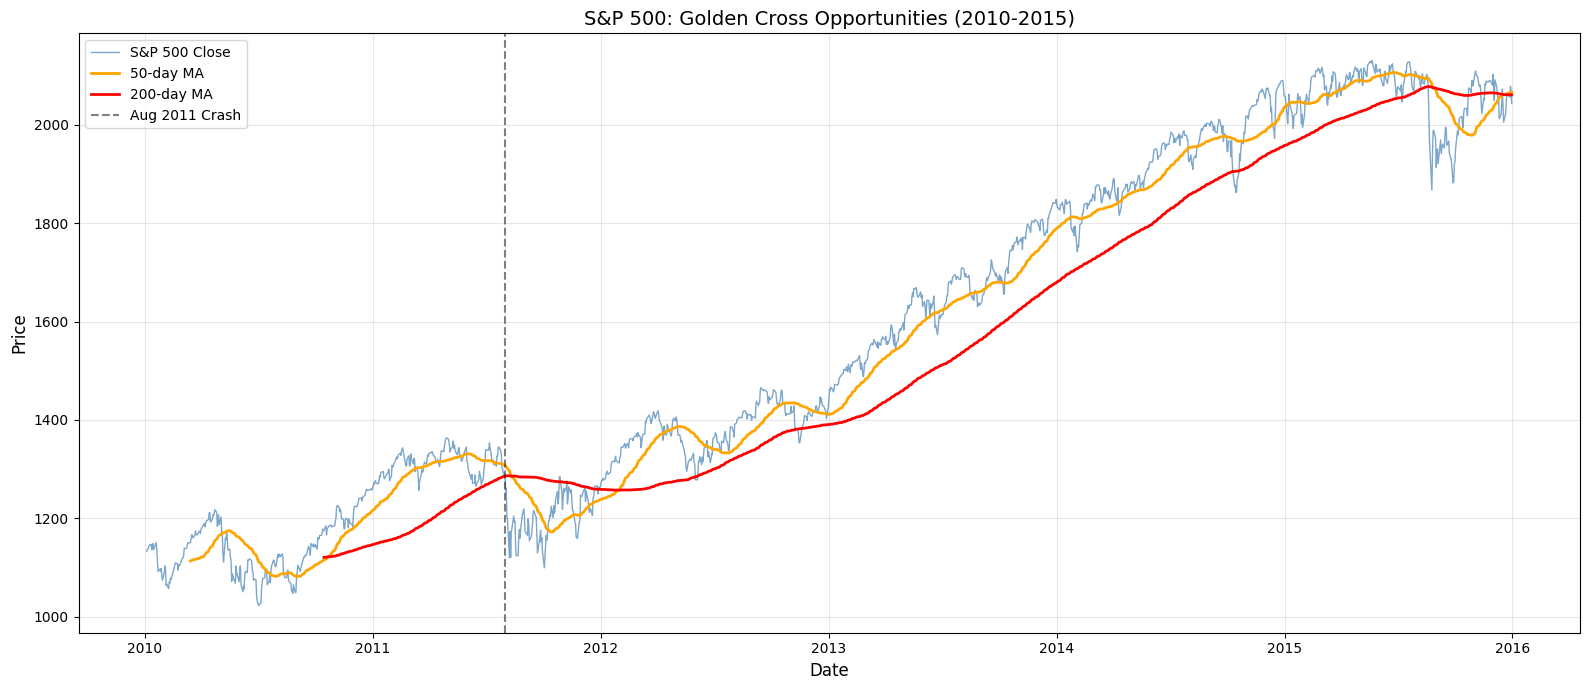

In [11]:
# Focus on 2011-2015 to see the Golden Crosses after the 2011 crash
start_date = '2010-01-01'
end_date = '2015-12-31'
subset = data[start_date:end_date].copy()

plt.figure(figsize=(16, 7))

plt.plot(subset.index, subset['Close'], label='S&P 500 Close', linewidth=1, color='steelblue', alpha=0.7)
plt.plot(subset.index, subset['MA50'], label='50-day MA', linewidth=2, color='orange')
plt.plot(subset.index, subset['MA200'], label='200-day MA', linewidth=2, color='red')

# Mark August 2011 crash
plt.axvline(x=pd.Timestamp('2011-08-01'), color='black', linestyle='--', alpha=0.5, label='Aug 2011 Crash')

plt.title('S&P 500: Golden Cross Opportunities (2010-2015)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Identify Golden Crosses (when MA50 crosses above MA200)
data['MA_Diff'] = data['MA50'] - data['MA200']
data['Signal'] = np.where(data['MA_Diff'] > 0, 1, 0)
data['Golden_Cross'] = data['Signal'].diff()

# Golden Crosses occur when Golden_Cross == 1
golden_crosses = data[data['Golden_Cross'] == 1].copy()

print("Golden Cross dates:")
print(golden_crosses[['Close', 'MA50', 'MA200']])

Golden Cross dates:
                  Close         MA50        MA200
Date                                             
2010-10-22  1183.079956  1122.469998  1121.559997
2012-01-31  1312.410034  1257.786003  1257.185302
2015-12-21  2021.150024  2061.505000  2061.409702
2016-04-25  2087.790039  2017.852197  2014.847349


In [13]:
# Analyze the bull markets following each Golden Cross
# Find when MA50 drops below MA200 again (end of bull market)

bull_markets = []
current_bull = None

for idx, row in data.iterrows():
    if row['Golden_Cross'] == 1:  # Golden Cross detected
        current_bull = {'start': idx, 'start_price': row['Close']}
    elif current_bull is not None and row['Signal'] == 0 and row['MA_Diff'] < 0:  # MA50 drops below MA200
        current_bull['end'] = idx
        current_bull['end_price'] = row['Close']
        bull_markets.append(current_bull)
        current_bull = None

print("Bull Markets Following Golden Crosses:")
for market in bull_markets:
    duration = (market['end'] - market['start']).days
    price_change = market['end_price'] - market['start_price']
    pct_change = (price_change / market['start_price']) * 100

    print(f"Start: {market['start'].date()} ({market['start_price']:.2f})")
    print(f"End: {market['end'].date()} ({market['end_price']:.2f})")
    print(f"Duration: {duration} days")
    print(f"Price change: {price_change:.2f} ({pct_change:.1f}%)\n")

Bull Markets Following Golden Crosses:
Start: 2010-10-22 (1183.08)
End: 2011-08-12 (1178.81)
Duration: 294 days
Price change: -4.27 (-0.4%)

Start: 2012-01-31 (1312.41)
End: 2015-08-28 (1988.87)
Duration: 1305 days
Price change: 676.46 (51.5%)

Start: 2015-12-21 (2021.15)
End: 2016-01-11 (1923.67)
Duration: 21 days
Price change: -97.48 (-4.8%)



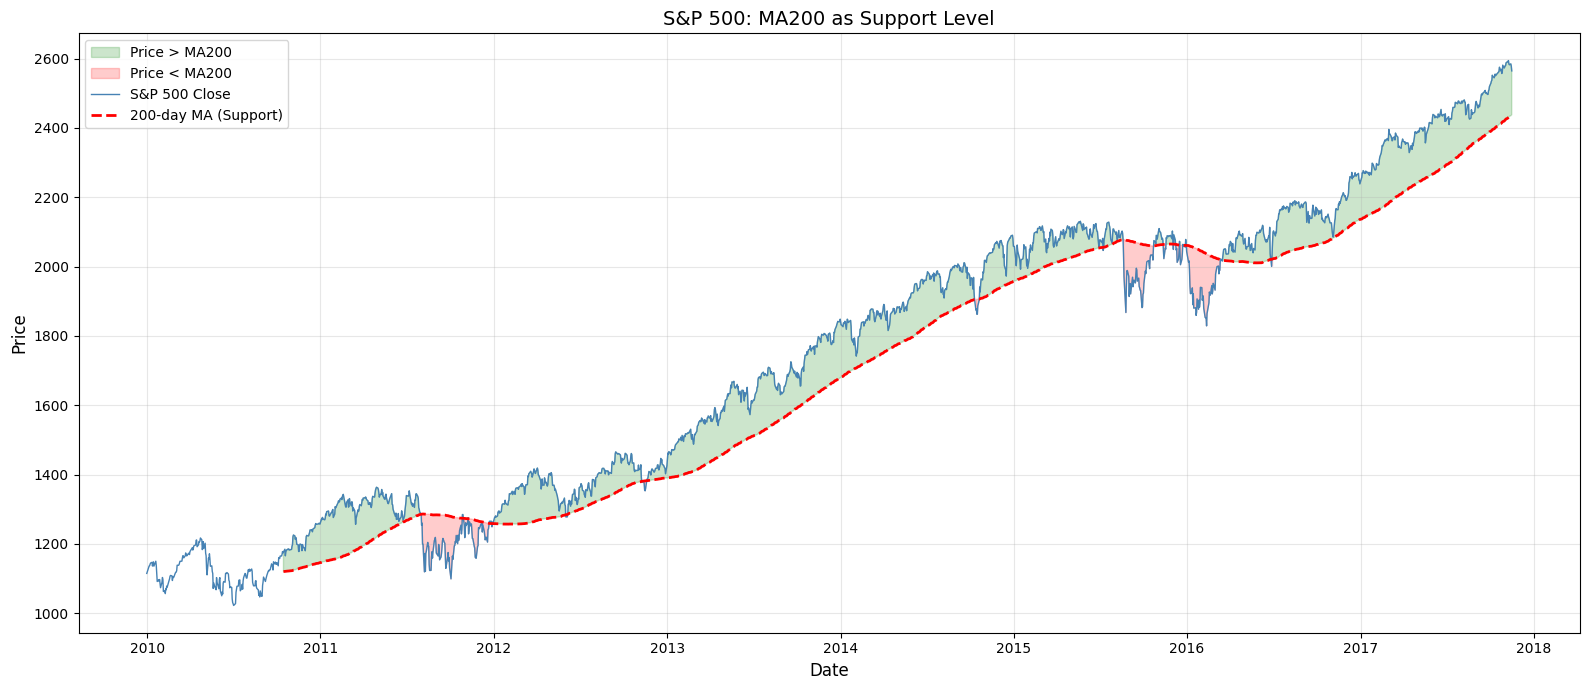

Number of trading days where price was within $10 of MA200: 51


In [14]:
# Check if MA200 acts as a support level
# Plot with focus on periods where price touches MA200

plt.figure(figsize=(16, 7))

plt.fill_between(data.index, data['MA200'], data['Close'],
                 where=(data['Close'] >= data['MA200']),
                 alpha=0.2, color='green', label='Price > MA200')
plt.fill_between(data.index, data['MA200'], data['Close'],
                 where=(data['Close'] < data['MA200']),
                 alpha=0.2, color='red', label='Price < MA200')

plt.plot(data.index, data['Close'], label='S&P 500 Close', linewidth=1, color='steelblue')
plt.plot(data.index, data['MA200'], label='200-day MA (Support)', linewidth=2, color='red', linestyle='--')

plt.title('S&P 500: MA200 as Support Level', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
times_touched = (abs(data['Close'] - data['MA200']) < 10).sum()
print(f"Number of trading days where price was within $10 of MA200: {times_touched}")

## References

Hoseinzade, E., & Haratizadeh, S. (2019-09). *CNNpred: CNN-based stock market prediction using a diverse set of variables.* Expert Systems with Applications, **129,** pp. 273–285. https://doi.org/10.1016/j.eswa.2019.03.029